## Download Data with Kaggle API and Install Libraries

Upload your kaggle.json to directory to download the data or download here [aged-synthetic-dataset](https://www.kaggle.com/datasets/penpentled/aged-synthetic-images)

In [111]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [112]:
!kaggle datasets download -d penpentled/aged-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/penpentled/aged-synthetic-images
License(s): CC0-1.0
aged-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [113]:
mkdir -p ./aged_synthetic_dataset

In [114]:
!unzip aged-synthetic-images.zip -d ./aged_synthetic_dataset

Archive:  aged-synthetic-images.zip
replace ./aged_synthetic_dataset/image_meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [ ]:
!pip install piq kornia pytorch-lightning

  Using cached piq-0.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached torchvision-0.21.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached torch-2.6.0-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
 

# Making Dataset

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import kornia

from torch.utils.data import Dataset, DataLoader

from PIL import Image
import pandas as pd
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

import random
from itertools import permutations
from tqdm import tqdm

In [4]:
TARGET_AGES = [18,23,28,33,38,43,48,53,58,63,68,73,78,83]
DATA_DIR = './aged_synthetic_dataset/synthetic_images/'

In [5]:
class FRANDataset(Dataset):
  def __init__(self, image_pairs, image_ages_dict, transforms, transform_resize):
    self.image_pairs = image_pairs
    self.image_ages_dict = image_ages_dict
    self.transforms = transforms
    self.transform_resize = transform_resize

  def __len__(self):
    return len(self.image_pairs)

  def __getitem__(self, index):
    image_pair = self.image_pairs[index]

    input_image = np.array(Image.open(DATA_DIR+image_pair[0]).convert('RGB'))
    target_image = np.array(Image.open(DATA_DIR+image_pair[1]).convert('RGB'))

    normalized_input_image_transformed = self.transforms(image=input_image)
    normalized_input_image = normalized_input_image_transformed['image']/127.5 - 1

    normalized_target_image = A.ReplayCompose.replay(normalized_input_image_transformed['replay'], image=np.array(target_image))['image']/127.5 - 1

    rgb_delta = normalized_target_image - normalized_input_image

    # Get age maps
    _,width,height=normalized_input_image.shape
    age_map1 = torch.full((1,width,height),self.image_ages_dict[image_pair[0]]/100)
    age_map2 = torch.full((1,width,height),self.image_ages_dict[image_pair[1]]/100)

    # Combine RGB delta diff with age maps for 5-channel tensor
    input_tensor = torch.cat((normalized_input_image, age_map1, age_map2), dim=0)

    return {
        'input': input_tensor,
        'normalized_input_image': normalized_input_image,
        'normalized_target_image': normalized_target_image,
        'target_age': age_map2,
      }

In [6]:
# Some augmentations
transform_normalize = A.ReplayCompose([
    A.Resize(512, 512),
    A.RandomCrop(256, 256),
    A.ColorJitter(p=0.8),
    A.Blur(p=0.1),
    A.RandomBrightnessContrast(),
    A.Affine(rotate=[-30, 30],scale=(0.5,1.5), p=0.8),
    ToTensorV2(),
])


transform_resize = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

In [7]:
image_meta = pd.read_csv('/home/andre/fran/aged_synthetic_dataset/image_meta.csv')

In [8]:
image_meta = image_meta.drop(columns=['Unnamed: 0'])

image_meta

,image_18,image_23,image_28,image_33,image_38,image_43,image_48,image_53,image_58,image_63,image_68,image_73,image_78,image_83
0,aged_images/18_seed0002.png,aged_images/23_seed0002.png,aged_images/28_seed0002.png,aged_images/33_seed0002.png,aged_images/38_seed0002.png,aged_images/43_seed0002.png,aged_images/48_seed0002.png,aged_images/53_seed0002.png,aged_images/58_seed0002.png,aged_images/63_seed0002.png,aged_images/68_seed0002.png,aged_images/73_seed0002.png,aged_images/78_seed0002.png,aged_images/83_seed0002.png
1,aged_images/18_seed0003.png,aged_images/23_seed0003.png,aged_images/28_seed0003.png,aged_images/33_seed0003.png,aged_images/38_seed0003.png,aged_images/43_seed0003.png,aged_images/48_seed0003.png,aged_images/53_seed0003.png,aged_images/58_seed0003.png,aged_images/63_seed0003.png,aged_images/68_seed0003.png,aged_images/73_seed0003.png,aged_images/78_seed0003.png,aged_images/83_seed0003.png
2,aged_images/18_seed0004.png,aged_images/23_seed0004.png,aged_images/28_seed0004.png,aged_images/33_seed0004.png,aged_images/38_seed0004.png,aged_images/43_seed0004.png,aged_images/48_seed0004.png,aged_images/53_seed0004.png,aged_images/58_seed0004.png,aged_images/63_seed0004.png,aged_images/68_seed0004.png,aged_images/73_seed0004.png,aged_images/78_seed0004.png,aged_images/83_seed0004.png
3,aged_images/18_seed0005.png,aged_images/23_seed0005.png,aged_images/28_seed0005.png,aged_images/33_seed0005.png,aged_images/38_seed0005.png,aged_images/43_seed0005.png,aged_images/48_seed0005.png,aged_images/53_seed0005.png,aged_images/58_seed0005.png,aged_images/63_seed0005.png,aged_images/68_seed0005.png,aged_images/73_seed0005.png,aged_images/78_seed0005.png,aged_images/83_seed0005.png
4,aged_images/18_seed0006.png,aged_images/23_seed0006.png,aged_images/28_seed0006.png,aged_images/33_seed0006.png,aged_images/38_seed0006.png,aged_images/43_seed0006.png,aged_images/48_seed0006.png,aged_images/53_seed0006.png,aged_images/58_seed0006.png,aged_images/63_seed0006.png,aged_images/68_seed0006.png,aged_images/73_seed0006.png,aged_images/78_seed0006.png,aged_images/83_seed0006.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,aged_images/18_seed1997.png,aged_images/23_seed1997.png,aged_images/28_seed1997.png,aged_images/33_seed1997.png,aged_images/38_seed1997.png,aged_images/43_seed1997.png,aged_images/48_seed1997.png,aged_images/53_seed1997.png,aged_images/58_seed1997.png,aged_images/63_seed1997.png,aged_images/68_seed1997.png,aged_images/73_seed1997.png,aged_images/78_seed1997.png,aged_images/83_seed1997.png
1996,aged_images/18_seed1998.png,aged_images/23_seed1998.png,aged_images/28_seed1998.png,aged_images/33_seed1998.png,aged_images/38_seed1998.png,aged_images/43_seed1998.png,aged_images/48_seed1998.png,aged_images/53_seed1998.png,aged_images/58_seed1998.png,aged_images/63_seed1998.png,aged_images/68_seed1998.png,aged_images/73_seed1998.png,aged_images/78_seed1998.png,aged_images/83_seed1998.png
1997,aged_images/18_seed1999.png,aged_images/23_seed1999.png,aged_images/28_seed1999.png,aged_images/33_seed1999.png,aged_images/38_seed1999.png,aged_images/43_seed1999.png,aged_images/48_seed1999.png,aged_images/53_seed1999.png,aged_images/58_seed1999.png,aged_images/63_seed1999.png,aged_images/68_seed1999.png,aged_images/73_seed1999.png,aged_images/78_seed1999.png,aged_images/83_seed1999.png
1998,aged_images/18_seed2000.png,aged_images/23_seed2000.png,aged_images/28_seed2000.png,aged_images/33_seed2000.png,aged_images/38_seed2000.png,aged_images/43_seed2000.png,aged_images/48_seed2000.png,aged_images/53_seed2000.png,aged_images/58_seed2000.png,aged_images/63_seed2000.png,aged_images/68_seed2000.png,aged_images/73_seed2000.png,aged_images/78_seed2000.png,aged_images/83_seed2000.png


In [9]:
# generate image age pairs
image_pairs = []

for _, row in image_meta.iterrows():
    image_paths = row.tolist()  # Convert the row to a list of image paths
    image_combinations = permutations(image_paths, 2)
    image_pairs.extend(list(image_combinations))

image_pairs[:5]

[('aged_images/18_seed0002.png', 'aged_images/23_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/28_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/33_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/38_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/43_seed0002.png')]

In [12]:
# generate image age dict {image path:age}
image_age_dict={}
for target_age, column in zip(TARGET_AGES,image_meta.columns):
  image_age_dict.update({path:target_age for path in image_meta[column].values})

print(list(image_age_dict.items())[:5])

[('aged_images/18_seed0002.png', 18), ('aged_images/18_seed0003.png', 18), ('aged_images/18_seed0004.png', 18), ('aged_images/18_seed0005.png', 18), ('aged_images/18_seed0006.png', 18)]


# Modeling

In [13]:
class BlurUpSample(nn.Module):
    def __init__(self, c):
        super(BlurUpSample, self).__init__()
        self.blurpool =  kornia.filters.GaussianBlur2d((3, 3), (1.5, 1.5))
        self.upsample = nn.Upsample(scale_factor=(2, 2), mode='bilinear', align_corners=False)

    def forward(self, x):
        x = self.blurpool(x)
        x = self.upsample(x)

        return x

class DownLayer(nn.Module):
    def __init__(self, c_in, c_out):
        super(DownLayer, self).__init__()
        self.maxblurpool = kornia.filters.MaxBlurPool2D(kernel_size=3)
        self.conv1 = nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(c_out)

    def forward(self, x):
        x = self.maxblurpool(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.leakyrelu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.leakyrelu(x)
        return x


class UpLayer(nn.Module):
    def __init__(self, c_in, c_out):
        super(UpLayer, self).__init__()
        self.upsample = BlurUpSample(c_in)
        self.conv1 = nn.Conv2d(c_in+ c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(c_out)

    def forward(self, x, skip_x):
        x = self.upsample(x)

        dh = skip_x.size(2) - x.size(2)
        dw = skip_x.size(3) - x.size(3)

        x = F.pad(x, (dw // 2, dw - dw // 2, dh // 2, dh - dh // 2))

        x = torch.cat([x, skip_x], dim=1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.leakyrelu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.leakyrelu(x)
        return x

In [14]:
# FRAN Unet Model
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.conv1 = nn.Conv2d(5, 64, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
    self.batchnorm1 = nn.BatchNorm2d(64)
    self.leakyrelu = nn.LeakyReLU(inplace=True)
    self.downlayer1 = DownLayer(64, 128)
    self.downlayer2 = DownLayer(128, 256)
    self.downlayer3 = DownLayer(256, 512)
    self.downlayer4 = DownLayer(512, 1024)
    self.uplayer1 = UpLayer(1024, 512)
    self.uplayer2 = UpLayer(512, 256)
    self.uplayer3 = UpLayer(256, 128)
    self.uplayer4 = UpLayer(128, 64)
    self.conv3 = nn.Conv2d(64, 3, kernel_size=1, stride=1, padding=0)

  def forward(self, x):
    #print(f'Input Shape: {x.shape}')
    x1 = self.conv1(x)
    x1 = self.batchnorm1(x1)
    x1 = self.leakyrelu(x1)
    x1 = self.conv2(x1)
    x1 = self.batchnorm1(x1)
    x1 = self.leakyrelu(x1)

    #print(f'Processed Input Shape: {x.shape}')

    x2 = self.downlayer1(x1)
    x3 = self.downlayer2(x2)
    x4 = self.downlayer3(x3)
    x5 = self.downlayer4(x4)

    #print(f'Done Downlayering... Shape: {x5.shape}')

    x = self.uplayer1(x5, x4)
    x = self.uplayer2(x, x3)
    x = self.uplayer3(x, x2)
    x = self.uplayer4(x, x1)
    x = self.conv3(x)

    #print(f'Output Shape: {x.shape}')
    return x

In [15]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()
        self.conv0 = nn.Conv2d(4, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.maxblurpool = kornia.filters.MaxBlurPool2D(kernel_size=3)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(512, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = self.conv0(x)
        x = self.bn1(x)
        x = self.leakyrelu(x)
        x = self.maxblurpool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.leakyrelu(x)
        x = self.maxblurpool(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.leakyrelu(x)
        x = self.maxblurpool(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.leakyrelu(x)
        x = self.conv5(x)

        return x

# Training Model

In [16]:
import torchvision.models as models
import torch.optim as optim
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from piq import LPIPS

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [19]:
dataset = FRANDataset(image_pairs, image_age_dict, transforms=transform_normalize, transform_resize=transform_resize)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

In [20]:
from torch.nn.modules import BCEWithLogitsLoss
# Define losses
adversarial_loss = BCEWithLogitsLoss()
l1_loss = nn.L1Loss()
perceptual_loss = LPIPS().to(device)

In [21]:
lambda_l1 = 1
lambda_perceptual = 1
lambda_adversarial = 0.05

In [22]:
# Basic pl lightning module for checkpointing and logging
class FRAN(pl.LightningModule):
  def __init__(self, generator, discriminator):
    super(FRAN, self).__init__()
    self.generator = generator
    self.discriminator =discriminator
    self.automatic_optimization = False
    self.my_step =0

  def forward(self, x):
      with torch.no_grad():
        model_output = self.generator(x)
      return model_output

  def training_step(self, batch, batch_idx):
      opt_g, opt_d = self.optimizers()

      opt_g.zero_grad()
      opt_d.zero_grad()


      inputs = batch['input'].to(self.device)
      normalized_input_image = batch['normalized_input_image'].to(self.device)
      normalized_target_image = batch['normalized_target_image'].to(self.device)


      target_age = batch['target_age'].to(self.device)
      # Forward pass
      outputs = self.generator(inputs)

      predicted_images = normalized_input_image+outputs
      predicted_images_with_age = torch.cat((predicted_images, target_age), dim=1)

      real_labels = torch.ones(inputs.shape[0], 1, 32, 32).to(self.device)
      fake_labels = torch.zeros(inputs.shape[0], 1, 32, 32).to(self.device)

      # Compute discriminator losses
      real_loss = adversarial_loss(self.discriminator(torch.cat((normalized_target_image, target_age), dim=1)), real_labels)
      fake_loss = adversarial_loss(self.discriminator(predicted_images_with_age.detach()), fake_labels)

      d_loss = (real_loss+fake_loss) / 2

      self.manual_backward(d_loss)
      opt_d.step()

      # Compute generator loss
      l1_loss_value = l1_loss(predicted_images, normalized_target_image)
      perceptual_loss_value = perceptual_loss(predicted_images, normalized_target_image)
      adversarial_loss_value = adversarial_loss(self.discriminator(predicted_images_with_age), real_labels)

      total_loss =  lambda_adversarial*adversarial_loss_value+ lambda_perceptual*perceptual_loss_value + lambda_l1*l1_loss_value

      self.manual_backward(total_loss)
      opt_g.step()

      # Log loss
      self.log('fake_loss', fake_loss, prog_bar=True)
      self.log('discriminator_loss', d_loss, prog_bar=True)
      self.log('total_loss', total_loss, prog_bar=True)
      self.log('gen_adversarial_loss', lambda_adversarial*adversarial_loss_value, prog_bar=True)
      self.log('perceptual_loss', perceptual_loss_value.mean()*lambda_perceptual, prog_bar=True)
      self.log('l1_loss', l1_loss_value*lambda_l1, prog_bar=True)

      # Display images every 500 steps
      if self.my_step % 100 == 0:

        sample_image = inputs[0]
        model_output = outputs.detach()

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 5, 1)
        plt.imshow(((normalized_input_image[0].cpu().permute(1,2,0).numpy()+1)*127.5).astype('uint'))
        plt.title(f"Input Image, Age: {int(sample_image[3][0][0]*100)}")
        plt.axis('off')

        plt.subplot(1, 5, 2)
        plt.imshow(((normalized_target_image[0].cpu().permute(1,2,0).numpy()+1)*127.5).astype('uint'))
        plt.title("Target Image")
        plt.axis('off')

        new_image = (((normalized_input_image[0].cpu()+model_output[0].cpu()).permute(1,2,0).numpy()+1)*127.5).astype('uint')
        plt.subplot(1, 5, 3)
        plt.imshow(new_image)
        plt.title(f"Output Image, Age: {int(sample_image[4][0][0]*100)}")
        plt.axis('off')

        new_image = (((torch.abs(normalized_target_image[0].cpu()-normalized_input_image[0].cpu())).permute(1,2,0).numpy()+1)*127.5).astype('uint')
        plt.subplot(1, 5, 4)
        plt.imshow(new_image)
        plt.title(f"Tar RGB Diff")
        plt.axis('off')

        new_image = (((torch.abs(model_output[0].cpu())).permute(1,2,0).numpy()+1)*127.5).astype('uint')
        plt.subplot(1, 5, 5)
        plt.imshow(new_image)
        plt.title(f"Pred RGB Diff")
        plt.axis('off')

        plt.show()

      self.my_step +=1

  def configure_optimizers(self):
    generator_optimizer = optim.Adam(self.generator.parameters(), lr=0.0001)
    discriminator_optimizer = optim.Adam(self.discriminator.parameters(), lr=0.0001)

    return [generator_optimizer, discriminator_optimizer]

In [23]:
fran_model = FRAN(Generator(), PatchGANDiscriminator())

In [24]:
import os
import pytorch_lightning as pl

# Create a directory within the current working directory, for example
checkpoint_dir = os.path.join(os.getcwd(), 'model_checkpoints')

# Ensure the directory exists
os.makedirs(checkpoint_dir, exist_ok=True)


fran_trainer = pl.Trainer(
  precision='16-mixed',
devices=1,
  max_epochs=20,
  callbacks =[ pl.callbacks.ModelCheckpoint(
    every_n_train_steps=5000,
    dirpath=checkpoint_dir,
    filename='fran-{step:05d}',
  )]
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [ ]:
fran_trainer.fit(fran_model, dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name          | Type                  | Params
--------------------------------------------------------
0 | generator     | Generator             | 31.4 M
1 | discriminator | PatchGANDiscriminator | 1.6 M 
--------------------------------------------------------
32.9 M    Trainable params
0         Non-trainable params
32.9 M    Total params
131.800   Total estimated model params size (MB)


Epoch 0:   0%|          | 0/45500 [00:00<?, ?it/s] 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46..258].


# Demo

Simple Demo: Crop out face and run the image through the model. https://huggingface.co/spaces/penpen/age-transformation  

In [26]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader

# Load model from checkpoint
def load_model_from_checkpoint(checkpoint_path, generator, discriminator):
    model = FRAN(generator, discriminator)
    model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))['state_dict'])
    model.eval()
    return model

# Define test function
def test_model(model, test_dataset, batch_size=1):
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            inputs = batch['input'].to(model.device)
            normalized_input_image = batch['normalized_input_image'].to(model.device)
            target_age = batch['target_age'].to(model.device)
            
            outputs = model(inputs)
            predicted_images = normalized_input_image + outputs
            
            # Convert images for visualization
            input_img = ((normalized_input_image[0].cpu().permute(1, 2, 0).numpy() + 1) * 127.5).astype('uint8')
            pred_img = ((predicted_images[0].cpu().permute(1, 2, 0).numpy() + 1) * 127.5).astype('uint8')
            
            # Display images
            import matplotlib.pyplot as plt
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(input_img)
            plt.title("Input Image")
            plt.axis("off")
            
            plt.subplot(1, 2, 2)
            plt.imshow(pred_img)
            plt.title("Predicted Image")
            plt.axis("off")
            
            plt.show()


# Load the generator and discriminator
generator = Generator()
discriminator = PatchGANDiscriminator()
checkpoint_path = "model_checkpoints/fran-step=1325000.ckpt"
model = load_model_from_checkpoint(checkpoint_path, generator, discriminator)

In [27]:
image_meta_test = pd.read_csv('/home/andre/fran/data-demo/image_meta.csv')
image_meta_test

,image_18,image_23,image_28,image_33,image_38,image_43,image_48,image_53,image_58,image_63,image_68,image_73,image_78,image_83
0,aged_images/18_seed0002.png,aged_images/23_seed0002.png,aged_images/28_seed0002.png,aged_images/33_seed0002.png,aged_images/38_seed0002.png,aged_images/43_seed0002.png,aged_images/48_seed0002.png,aged_images/53_seed0002.png,aged_images/58_seed0002.png,aged_images/63_seed0002.png,aged_images/68_seed0002.png,aged_images/73_seed0002.png,aged_images/78_seed0002.png,aged_images/83_seed0002.png
1,aged_images/18_seed0003.png,aged_images/23_seed0003.png,aged_images/28_seed0003.png,aged_images/33_seed0003.png,aged_images/38_seed0003.png,aged_images/43_seed0003.png,aged_images/48_seed0003.png,aged_images/53_seed0003.png,aged_images/58_seed0003.png,aged_images/63_seed0003.png,aged_images/68_seed0003.png,aged_images/73_seed0003.png,aged_images/78_seed0003.png,aged_images/83_seed0003.png
2,aged_images/18_seed0004.png,aged_images/23_seed0004.png,aged_images/28_seed0004.png,aged_images/33_seed0004.png,aged_images/38_seed0004.png,aged_images/43_seed0004.png,aged_images/48_seed0004.png,aged_images/53_seed0004.png,aged_images/58_seed0004.png,aged_images/63_seed0004.png,aged_images/68_seed0004.png,aged_images/73_seed0004.png,aged_images/78_seed0004.png,aged_images/83_seed0004.png
3,aged_images/18_seed0005.png,aged_images/23_seed0005.png,aged_images/28_seed0005.png,aged_images/33_seed0005.png,aged_images/38_seed0005.png,aged_images/43_seed0005.png,aged_images/48_seed0005.png,aged_images/53_seed0005.png,aged_images/58_seed0005.png,aged_images/63_seed0005.png,aged_images/68_seed0005.png,aged_images/73_seed0005.png,aged_images/78_seed0005.png,aged_images/83_seed0005.png
4,aged_images/18_seed0006.png,aged_images/23_seed0006.png,aged_images/28_seed0006.png,aged_images/33_seed0006.png,aged_images/38_seed0006.png,aged_images/43_seed0006.png,aged_images/48_seed0006.png,aged_images/53_seed0006.png,aged_images/58_seed0006.png,aged_images/63_seed0006.png,aged_images/68_seed0006.png,aged_images/73_seed0006.png,aged_images/78_seed0006.png,aged_images/83_seed0006.png
5,aged_images/18_seed0007.png,aged_images/23_seed0007.png,aged_images/28_seed0007.png,aged_images/33_seed0007.png,aged_images/38_seed0007.png,aged_images/43_seed0007.png,aged_images/48_seed0007.png,aged_images/53_seed0007.png,aged_images/58_seed0007.png,aged_images/63_seed0007.png,aged_images/68_seed0007.png,aged_images/73_seed0007.png,aged_images/78_seed0007.png,aged_images/83_seed0007.png
6,aged_images/18_seed0008.png,aged_images/23_seed0008.png,aged_images/28_seed0008.png,aged_images/33_seed0008.png,aged_images/38_seed0008.png,aged_images/43_seed0008.png,aged_images/48_seed0008.png,aged_images/53_seed0008.png,aged_images/58_seed0008.png,aged_images/63_seed0008.png,aged_images/68_seed0008.png,aged_images/73_seed0008.png,aged_images/78_seed0008.png,aged_images/83_seed0008.png
7,aged_images/18_seed0009.png,aged_images/23_seed0009.png,aged_images/28_seed0009.png,aged_images/33_seed0009.png,aged_images/38_seed0009.png,aged_images/43_seed0009.png,aged_images/48_seed0009.png,aged_images/53_seed0009.png,aged_images/58_seed0009.png,aged_images/63_seed0009.png,aged_images/68_seed0009.png,aged_images/73_seed0009.png,aged_images/78_seed0009.png,aged_images/83_seed0009.png
8,aged_images/18_seed0010.png,aged_images/23_seed0010.png,aged_images/28_seed0010.png,aged_images/33_seed0010.png,aged_images/38_seed0010.png,aged_images/43_seed0010.png,aged_images/48_seed0010.png,aged_images/53_seed0010.png,aged_images/58_seed0010.png,aged_images/63_seed0010.png,aged_images/68_seed0010.png,aged_images/73_seed0010.png,aged_images/78_seed0010.png,aged_images/83_seed0010.png
9,aged_images/18_seed0011.png,aged_images/23_seed0011.png,aged_images/28_seed0011.png,aged_images/33_seed0011.png,aged_images/38_seed0011.png,aged_images/43_seed0011.png,aged_images/48_seed0011.png,aged_images/53_seed0011.png,aged_images/58_seed0011.png,aged_images/63_seed0011.png,aged_images/68_seed0011.png,aged_images/73_se

In [28]:
# generate image age pairs
image_pairs_test = []

for _, row in image_meta_test.iterrows():
    image_paths_test = row.tolist()  # Convert the row to a list of image paths
    image_combinations = permutations(image_paths_test, 2)
    image_pairs_test.extend(list(image_combinations))

image_pairs_test[:5]

[('aged_images/18_seed0002.png', 'aged_images/23_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/28_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/33_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/38_seed0002.png'),
 ('aged_images/18_seed0002.png', 'aged_images/43_seed0002.png')]

In [31]:
# Reshape the DataFrame: Convert wide format to long format
image_meta_long = image_meta_test.melt(var_name="age", value_name="image_path")

# Convert age column names from "mage_18" to just "18"
image_meta_long["age"] = image_meta_long["age"].str.extract(r'(\d+)').astype(int)

# Create the dictionary
image_age_dict_test = dict(zip(image_meta_long["image_path"], image_meta_long["age"]))

# Print a few entries to verify
print(list(image_age_dict_test.items())[:5])


[('aged_images/18_seed0002.png', 18), ('aged_images/18_seed0003.png', 18), ('aged_images/18_seed0004.png', 18), ('aged_images/18_seed0005.png', 18), ('aged_images/18_seed0006.png', 18)]


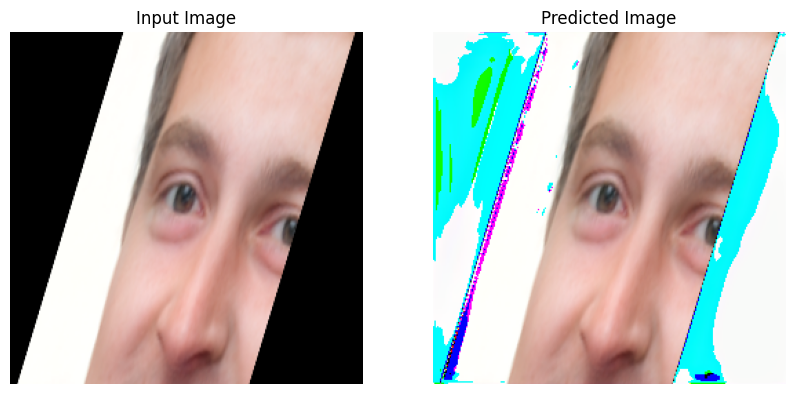

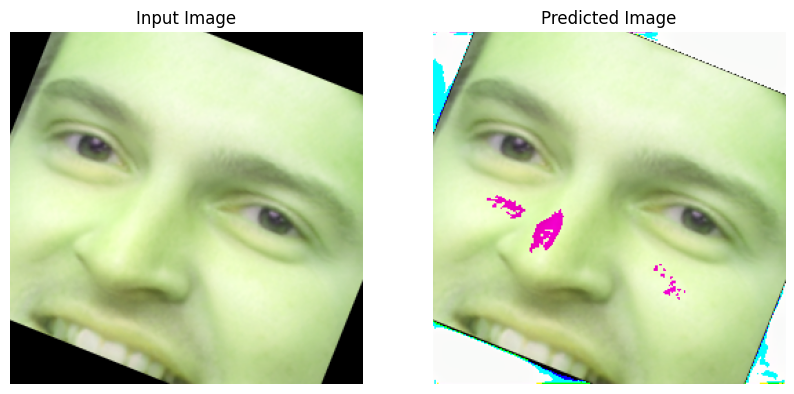

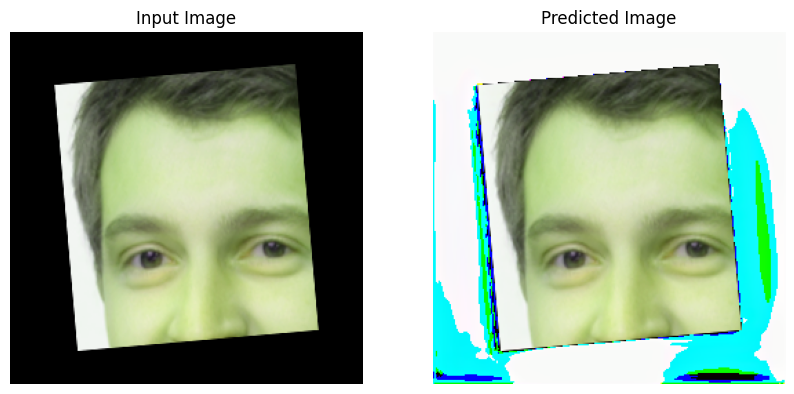

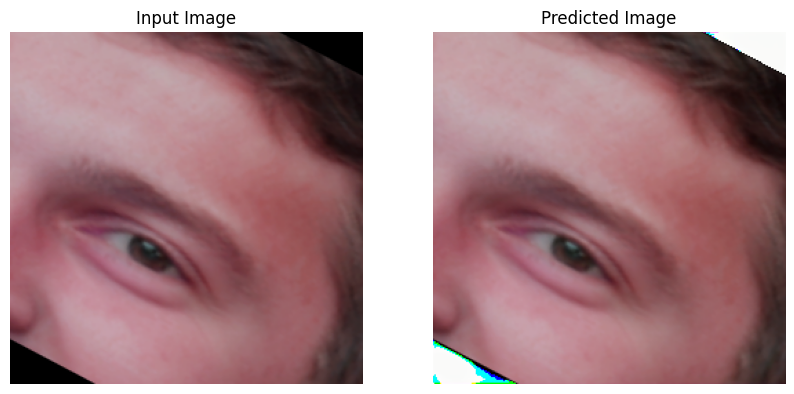

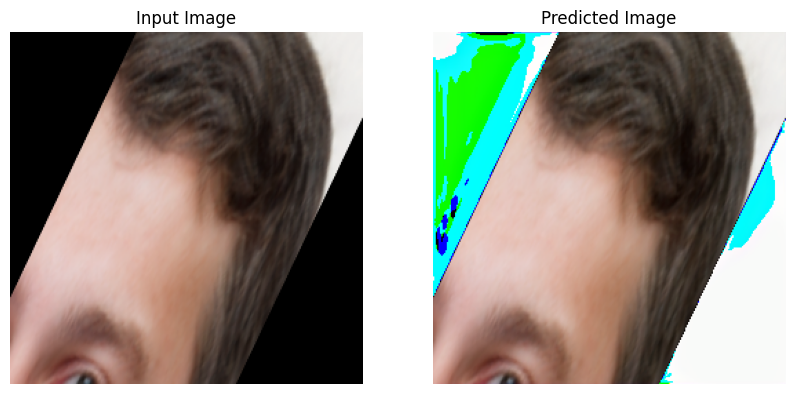

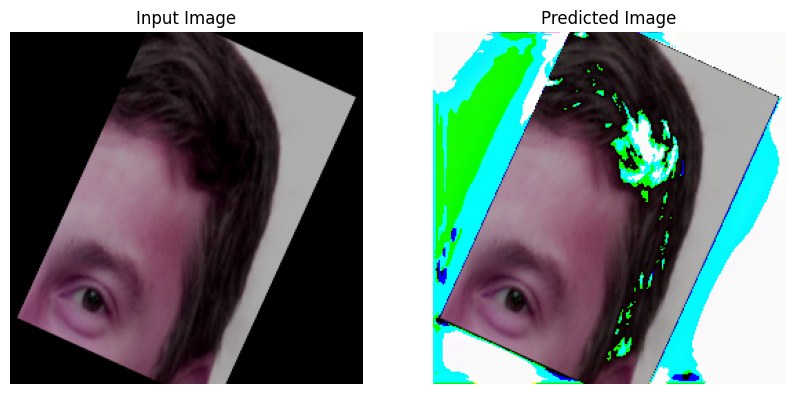

In [33]:
# Load the test dataset (ensure `test_dataset` is defined beforehand)
test_dataset = FRANDataset(image_pairs_test, image_age_dict_test, transform_normalize, transform_resize)
test_model(model, test_dataset)

In [34]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def test_model(model, test_dataset):
    model.eval()
    dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            inputs = batch['input'].to(model.device)
            normalized_input_image = batch['normalized_input_image'].to(model.device)
            normalized_target_image = batch['normalized_target_image'].to(model.device)
            target_age = batch['target_age'].to(model.device)

            # Forward pass
            outputs = model.generator(inputs)
            predicted_images = normalized_input_image + outputs
            predicted_images_with_age = torch.cat((predicted_images, target_age), dim=1)

            # Compute losses (without updating gradients)
            l1_loss_value = l1_loss(predicted_images, normalized_target_image)
            perceptual_loss_value = perceptual_loss(predicted_images, normalized_target_image)
            adversarial_loss_value = adversarial_loss(model.discriminator(predicted_images_with_age), torch.ones_like(predicted_images_with_age))

            total_loss = (
                lambda_adversarial * adversarial_loss_value + 
                lambda_perceptual * perceptual_loss_value + 
                lambda_l1 * l1_loss_value
            )

            # Logging
            print(f"Step {i}:")
            print(f"  L1 Loss: {l1_loss_value.item():.4f}")
            print(f"  Perceptual Loss: {perceptual_loss_value.item():.4f}")
            print(f"  Adversarial Loss: {adversarial_loss_value.item():.4f}")
            print(f"  Total Loss: {total_loss.item():.4f}")

            # Display images every 100 steps
            if i % 100 == 0:
                sample_image = inputs[0]
                model_output = outputs.detach()

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 5, 1)
                plt.imshow(((normalized_input_image[0].cpu().permute(1,2,0).numpy()+1)*127.5).astype('uint8'))
                plt.title(f"Input Image, Age: {int(sample_image[3][0][0]*100)}")
                plt.axis('off')

                plt.subplot(1, 5, 2)
                plt.imshow(((normalized_target_image[0].cpu().permute(1,2,0).numpy()+1)*127.5).astype('uint8'))
                plt.title("Target Image")
                plt.axis('off')

                new_image = (((normalized_input_image[0].cpu()+model_output[0].cpu()).permute(1,2,0).numpy()+1)*127.5).astype('uint8')
                plt.subplot(1, 5, 3)
                plt.imshow(new_image)
                plt.title(f"Output Image, Age: {int(sample_image[4][0][0]*100)}")
                plt.axis('off')

                new_image = (((torch.abs(normalized_target_image[0].cpu()-normalized_input_image[0].cpu())).permute(1,2,0).numpy()+1)*127.5).astype('uint8')
                plt.subplot(1, 5, 4)
                plt.imshow(new_image)
                plt.title("Tar RGB Diff")
                plt.axis('off')

                new_image = (((torch.abs(model_output[0].cpu())).permute(1,2,0).numpy()+1)*127.5).astype('uint8')
                plt.subplot(1, 5, 5)
                plt.imshow(new_image)
                plt.title("Pred RGB Diff")
                plt.axis('off')

                plt.show()


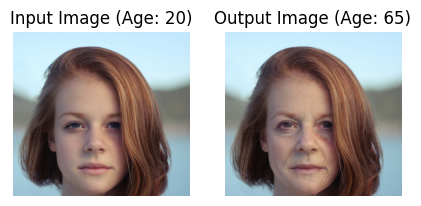

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import kornia
import matplotlib.pyplot as plt

from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define model components
class BlurUpSample(nn.Module):
    def __init__(self, c):
        super(BlurUpSample, self).__init__()
        self.blurpool = kornia.filters.GaussianBlur2d((3, 3), (1.5, 1.5))
        self.upsample = nn.Upsample(scale_factor=(2, 2), mode='bilinear', align_corners=False)

    def forward(self, x):
        x = self.blurpool(x)
        x = self.upsample(x)
        return x

class DownLayer(nn.Module):
    def __init__(self, c_in, c_out):
        super(DownLayer, self).__init__()
        self.maxblurpool = kornia.filters.MaxBlurPool2D(kernel_size=3)
        self.conv1 = nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(c_out)

    def forward(self, x):
        x = self.maxblurpool(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.leakyrelu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.leakyrelu(x)
        return x

class UpLayer(nn.Module):
    def __init__(self, c_in, c_out):
        super(UpLayer, self).__init__()
        self.upsample = BlurUpSample(c_in)
        self.conv1 = nn.Conv2d(c_in + c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(c_out)

    def forward(self, x, skip_x):
        x = self.upsample(x)
        dh = skip_x.size(2) - x.size(2)
        dw = skip_x.size(3) - x.size(3)
        x = F.pad(x, (dw // 2, dw - dw // 2, dh // 2, dh - dh // 2))
        x = torch.cat([x, skip_x], dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.leakyrelu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.leakyrelu(x)
        return x

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.conv1 = nn.Conv2d(5, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(64)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.downlayer1 = DownLayer(64, 128)
        self.downlayer2 = DownLayer(128, 256)
        self.downlayer3 = DownLayer(256, 512)
        self.downlayer4 = DownLayer(512, 1024)
        self.uplayer1 = UpLayer(1024, 512)
        self.uplayer2 = UpLayer(512, 256)
        self.uplayer3 = UpLayer(256, 128)
        self.uplayer4 = UpLayer(128, 64)
        self.conv3 = nn.Conv2d(64, 3, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x1 = self.conv1(x)
        x1 = self.batchnorm1(x1)
        x1 = self.leakyrelu(x1)
        x1 = self.conv2(x1)
        x1 = self.batchnorm1(x1)
        x1 = self.leakyrelu(x1)
        x2 = self.downlayer1(x1)
        x3 = self.downlayer2(x2)
        x4 = self.downlayer3(x3)
        x5 = self.downlayer4(x4)
        x = self.uplayer1(x5, x4)
        x = self.uplayer2(x, x3)
        x = self.uplayer3(x, x2)
        x = self.uplayer4(x, x1)
        x = self.conv3(x)
        return x

transform_resize = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

# # Load model
# generator_model = Generator()
# # checkpoint_path = "model_checkpoints/fran-step=1325000.ckpt"
# checkpoint_path = "large-aging-model.h5"

# generator_model = load_model_from_checkpoint(checkpoint_path, generator, discriminator)
# generator_model.to(device)
# # generator_model.eval()


# Load model
generator_model = Generator()
generator_model.load_state_dict(torch.load('large-aging-model.h5',map_location=torch.device(device)))
generator_model.to(device)
#generator_model.eval()
print("")

# Function to process images
def age_filter(image, input_age, output_age):
    resized_image = image.resize((512, 512))
    input_image = transform_resize(image=np.array(image))['image'] / 255
    age_map1 = torch.full((1, 512, 512), input_age / 100)
    age_map2 = torch.full((1, 512, 512), output_age / 100)
    input_tensor = torch.cat((input_image, age_map1, age_map2), dim=0)
    
    with torch.no_grad():
        model_output = generator_model(input_tensor.unsqueeze(0).to(device))

    np_test = np.array(image)
    
    new_image = (model_output.squeeze(0).cpu().permute(1, 2, 0).numpy() * 255 + np.array(resized_image)).astype('uint8')

    sample_image = np.array(Image.fromarray(new_image).resize((np_test.shape[1],np_test.shape[0]))).astype('uint8')
    return sample_image

# Load an example image and test the function
def process_and_show_image(image_path, input_age, output_age):
    image = Image.open(image_path).convert("RGB")
    output_image = age_filter(image, input_age, output_age)

    # Display images
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    axes[0].imshow(image)
    axes[0].set_title(f"Input Image (Age: {input_age})")
    axes[0].axis("off")

    axes[1].imshow(output_image)
    axes[1].set_title(f"Output Image (Age: {output_age})")
    axes[1].axis("off")

    plt.show()

# Example usage
process_and_show_image("/home/andre/fran/example-images/input_example_img.png", 20, 65)

In [35]:
import gradio as gr
from torchvision.transforms.functional import crop

def crop_and_process_image(input_img,input_age,output_ag):
    # Crop the image using the provided crop tool coordinates
    processed_image = Image.fromarray(input_img)  # Modify this line to preprocess the cropped image

    # Run the processed image through your model
    output = age_filter(processed_image, input_age, output_ag)
    # Return the output
    return output

input_image = gr.Image(label="Input Image", interactive=True)

output_image = gr.Image(label="Output Image", type="pil")

input_age = gr.Slider(label="Current Age",minimum=18,maximum=80)
output_age = gr.Slider(label="Desired Age",minimum=18,maximum=80)


def process_image(input_img,input_age,output_age):

    output = crop_and_process_image(input_img,input_age,output_age)

    output = Image.fromarray(output)
    return output
    
description="Enter age of input image and desired age. Crop out background. Better results on high resolution (512x512 face). To avoid background/hair artifacts, use with a face parser." 



# Create the Gradio interface
gr.Interface(fn=process_image, inputs=[input_image,input_age,output_age], outputs=output_image,description=description, title="Age Transformation",cache_examples = True, examples=[["example_image_input2.jpeg",30,65],["example_image_output.png",20,40]]).launch()


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/fastapi/applications.py", line 1054, in __call__
    await super().__call__(scope, receive, send)
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/starlette/applications.py", line 112, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/starlette/middleware/errors.py", line 187, i

* Running on local URL:  http://127.0.0.1:7860
Caching examples at: '/home/andre/fran/.gradio/cached_examples/17'

To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/gradio/routes.py", line 1023, in predict
    output = await route_utils.call_process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/gradio/blocks.py", line 2103, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/gradio/blocks.py", line 1650, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andre/anaconda3/envs/fran/lib/python3.12/site-packages/anyio/to_thread.py", line 56,